# BBH Remnants: Nonprecessing Models

In [1]:
import warnings
warnings.filterwarnings('ignore', 'Wswiglal-redir-stdio')

from gwGenealogy.binaries import BBHs, BBHRemnant, sample_masses, sample_spins
from gwGenealogy.utils import compute_jensen_shannon_divergence
from gwGenealogy.utils import set_rcparams
import numpy as np
import matplotlib.pyplot as plt

set_rcparams()

lal.MSUN_SI != Msun


## Sample BBH population

In [2]:
N = 5000
m1, m2 = sample_masses(N, m_min=5, m_max=50, m1_distribution='powerlaw', alpha=-2.35, seed=42)
chi1, chi2 = sample_spins(N, chi_max=0.5, spin_magnitude='uniform', spin_angles='isotropic', seed=43)

bbh = BBHs(
    m1=m1, m2=m2,
    a1=np.linalg.norm(chi1, axis=1),
    a2=np.linalg.norm(chi2, axis=1),
    theta1=np.arccos(chi1[:, 2] / np.linalg.norm(chi1, axis=1)),
    theta2=np.arccos(chi2[:, 2] / np.linalg.norm(chi2, axis=1)),
    phi1=np.arctan2(chi1[:, 1], chi1[:, 0]) % (2 * np.pi),
    phi2=np.arctan2(chi2[:, 1], chi2[:, 0]) % (2 * np.pi),
)
print(bbh)

## Nonprecessing remnants: default (UIB + gwmodel_kick_q200)

In [3]:
rem1 = BBHRemnant(bbh=bbh, precessing=False)
print(rem1)

BBHRemnant(n=5000, precessing=False, mass_spin=uib, kick=gwmodel_kick_q200, Mf=[9.6, 87.8], af=[-0.011, 0.795], vkick=[0.4, 287.9] km/s)


## Alternative: HBR + HLZ

In [4]:
rem2 = BBHRemnant(bbh=bbh, precessing=False, mass_spin_model='hbr', kick_model='hlz')
print(rem2)

BBHRemnant(n=5000, precessing=False, mass_spin=hbr, kick=hlz, Mf=[9.6, 87.7], af=[0.087, 0.797], vkick=[0.3, 285.2] km/s)


## Remnant distributions

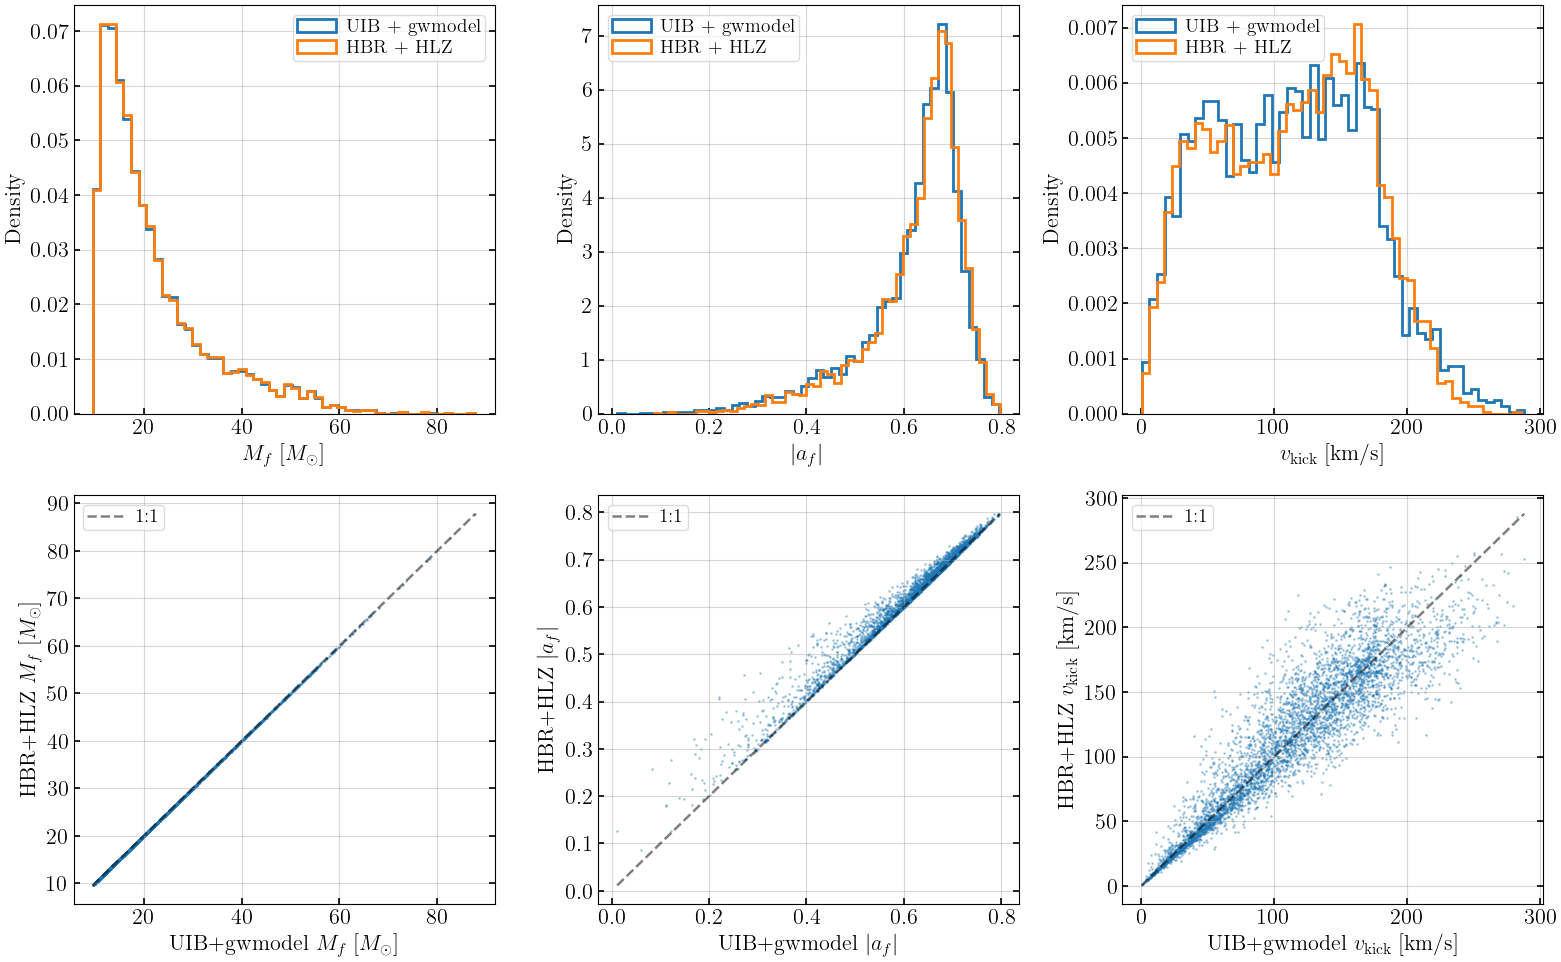

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- Row 1: density histograms ---
for ax, v1, v2, label in zip(
    axes[0],
    [rem1.Mf, np.abs(rem1.af), rem1.vkick],
    [rem2.Mf, np.abs(rem2.af), rem2.vkick],
    [r'$M_f\;[M_\odot]$', r'$|a_f|$', r'$v_{\rm kick}\;[{\rm km/s}]$'],
):
    ax.hist(v1, bins=50, density=True, histtype='step', lw=2, label='UIB + gwmodel')
    ax.hist(v2, bins=50, density=True, histtype='step', lw=2, label='HBR + HLZ')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=14)

# --- Row 2: scatter rem1 vs rem2 ---
for ax, v1, v2, label in zip(
    axes[1],
    [rem1.Mf, np.abs(rem1.af), rem1.vkick],
    [rem2.Mf, np.abs(rem2.af), rem2.vkick],
    [r'$M_f\;[M_\odot]$', r'$|a_f|$', r'$v_{\rm kick}\;[{\rm km/s}]$'],
):
    ax.scatter(v1, v2, s=1, alpha=0.3)
    lims = [min(v1.min(), v2.min()), max(v1.max(), v2.max())]
    ax.plot(lims, lims, 'k--', alpha=0.5, label='1:1')
    ax.set_xlabel(f'UIB+gwmodel {label}')
    ax.set_ylabel(f'HBR+HLZ {label}')
    ax.legend(fontsize=14)

plt.tight_layout()
plt.show()

## JSD between models

In [6]:
jsd_Mf = compute_jensen_shannon_divergence(rem1.Mf, rem2.Mf)
jsd_af = compute_jensen_shannon_divergence(np.abs(rem1.af), np.abs(rem2.af))
jsd_vk = compute_jensen_shannon_divergence(rem1.vkick, rem2.vkick)

print(f"JSD(Mf):    {jsd_Mf:.4f}")
print(f"JSD(|af|):  {jsd_af:.4f}")
print(f"JSD(vkick): {jsd_vk:.4f}")

JSD(Mf):    0.0003
JSD(|af|):  0.0047
JSD(vkick): 0.0066


## Remnant properties vs binary parameters

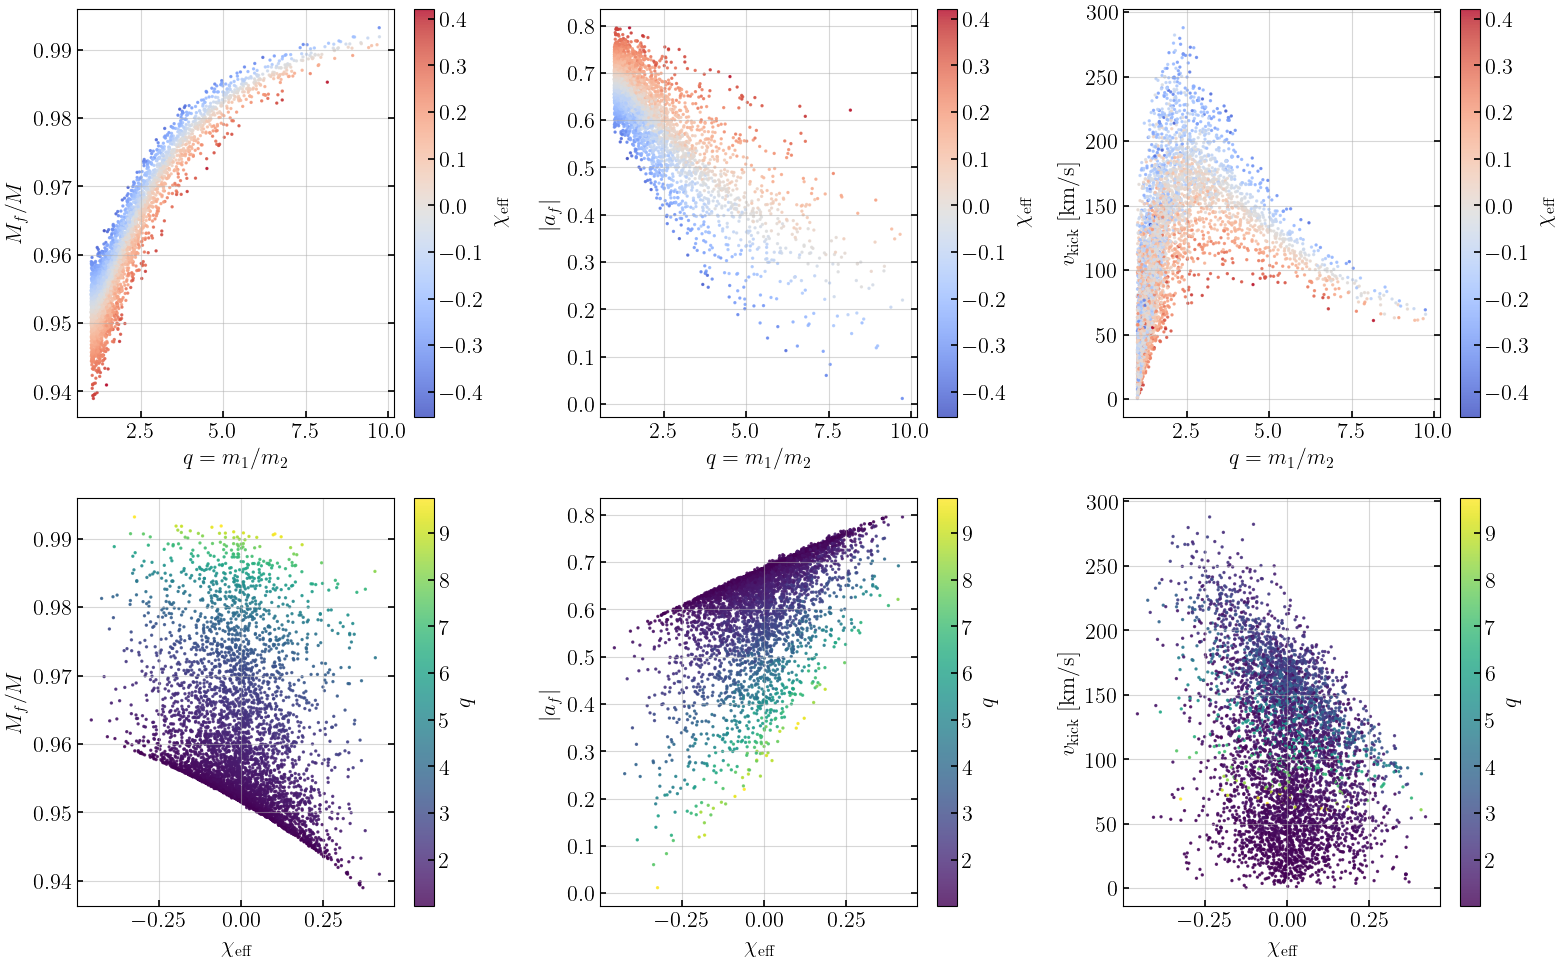

In [7]:
q = bbh.q
chi_eff_vals = bbh.chi_eff
Mf_frac = rem1.Mf / bbh.M
af_abs = np.abs(rem1.af)
vk = rem1.vkick

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- Top row: color by chi_eff ---
sc0 = axes[0, 0].scatter(q, Mf_frac, c=chi_eff_vals, s=2, alpha=0.8, cmap='coolwarm')
axes[0, 0].set_xlabel(r'$q = m_1/m_2$')
axes[0, 0].set_ylabel(r'$M_f / M$')
plt.colorbar(sc0, ax=axes[0, 0], label=r'$\chi_{\rm eff}$')

sc1 = axes[0, 1].scatter(q, af_abs, c=chi_eff_vals, s=2, alpha=0.8, cmap='coolwarm')
axes[0, 1].set_xlabel(r'$q = m_1/m_2$')
axes[0, 1].set_ylabel(r'$|a_f|$')
plt.colorbar(sc1, ax=axes[0, 1], label=r'$\chi_{\rm eff}$')

sc2 = axes[0, 2].scatter(q, vk, c=chi_eff_vals, s=2, alpha=0.8, cmap='coolwarm')
axes[0, 2].set_xlabel(r'$q = m_1/m_2$')
axes[0, 2].set_ylabel(r'$v_{\rm kick}\;[{\rm km/s}]$')
plt.colorbar(sc2, ax=axes[0, 2], label=r'$\chi_{\rm eff}$')

# --- Bottom row: color by q ---
sc3 = axes[1, 0].scatter(chi_eff_vals, Mf_frac, c=q, s=2, alpha=0.8, cmap='viridis')
axes[1, 0].set_xlabel(r'$\chi_{\rm eff}$')
axes[1, 0].set_ylabel(r'$M_f / M$')
plt.colorbar(sc3, ax=axes[1, 0], label=r'$q$')

sc4 = axes[1, 1].scatter(chi_eff_vals, af_abs, c=q, s=2, alpha=0.8, cmap='viridis')
axes[1, 1].set_xlabel(r'$\chi_{\rm eff}$')
axes[1, 1].set_ylabel(r'$|a_f|$')
plt.colorbar(sc4, ax=axes[1, 1], label=r'$q$')

sc5 = axes[1, 2].scatter(chi_eff_vals, vk, c=q, s=2, alpha=0.8, cmap='viridis')
axes[1, 2].set_xlabel(r'$\chi_{\rm eff}$')
axes[1, 2].set_ylabel(r'$v_{\rm kick}\;[{\rm km/s}]$')
plt.colorbar(sc5, ax=axes[1, 2], label=r'$q$')

plt.tight_layout()
plt.show()